In [1]:
import pandas as pd
import numpy as np

pd.set_option('max_colwidth', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

from ipywidgets import interact
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np

pd.set_option('max_colwidth', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

from ipywidgets import interact
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Read the dataset
data = pd.read_csv('Crop_recommendation.csv')

# Display first 5 rows
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# Shape of dataset - rows and columns
data.shape

(2200, 8)

In [5]:
# Column names
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [6]:
# Data types of each column
data.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [7]:
# Statistical summary
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
# Check dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [9]:
# Count of each crop in the dataset
data['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [10]:
data = pd.read_csv('Crop_recommendation.csv')

In [2]:
import pandas as pd
import numpy as np

pd.set_option('max_colwidth', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

from ipywidgets import interact
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
data = pd.read_csv('Crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<Figure size 1500x1000 with 0 Axes>

Text(0.5, 0.98, 'Distribution of agricultural conditions')

<Axes: >

/tmp/ipykernel_101102/1363891640.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[feature], color=color)


<Axes: xlabel='N', ylabel='Density'>

...

<Axes: >

/tmp/ipykernel_101102/1363891640.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[feature], color=color)


<Axes: xlabel='rainfall', ylabel='Density'>

Text(0.5, 0, 'Ratio of Rainfall')

Text(0, 0.5, 'Density')

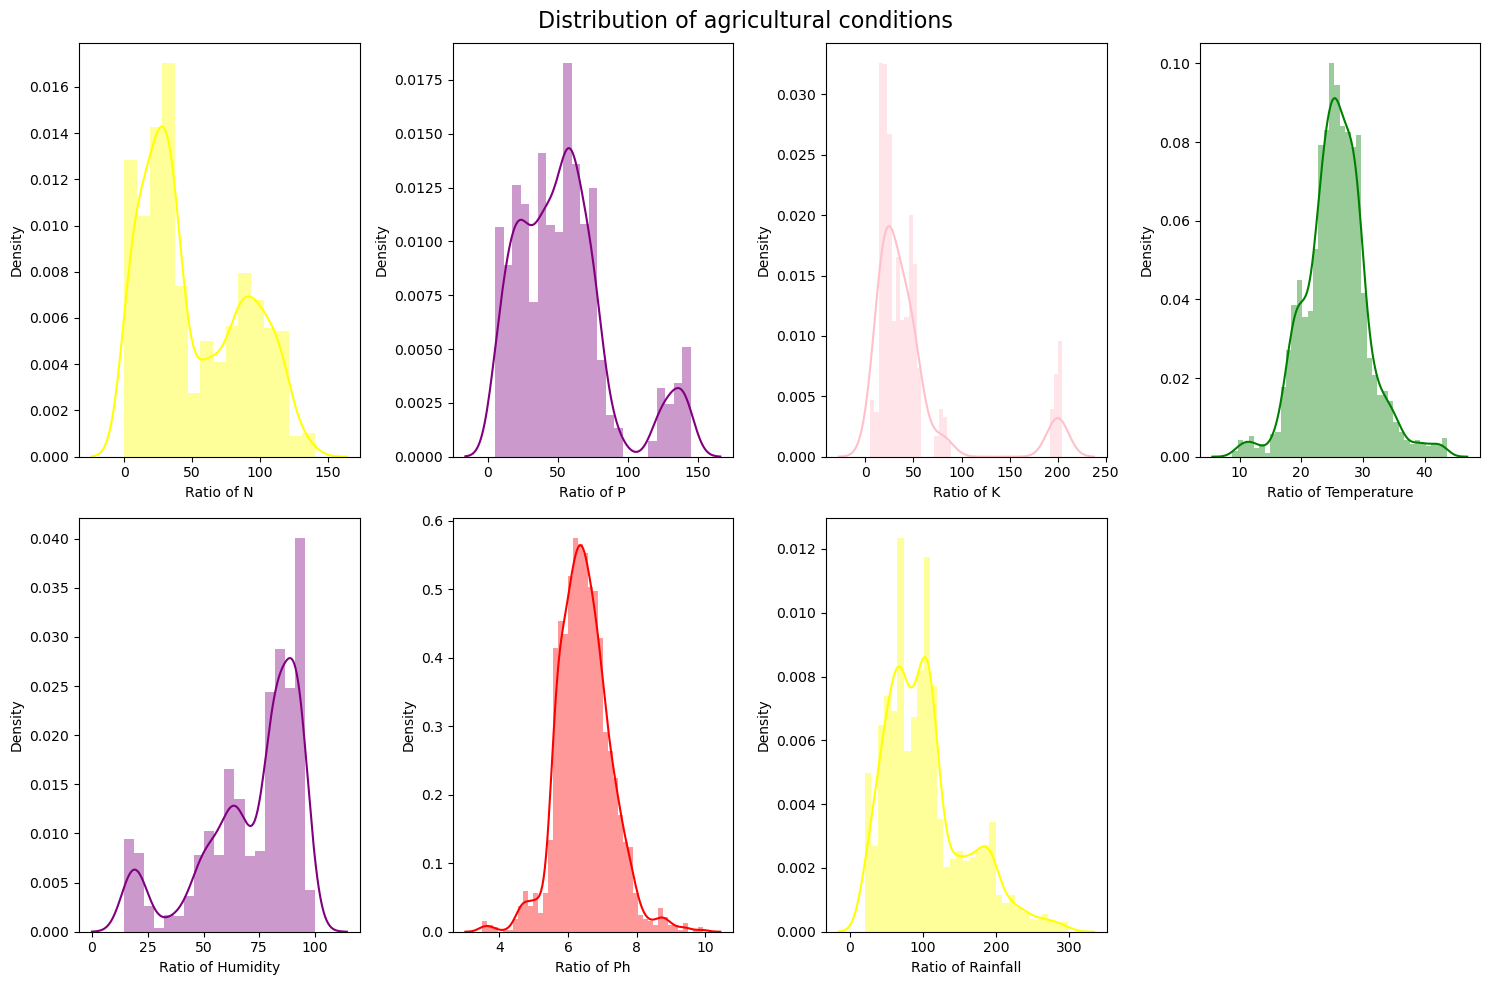

In [4]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors = ['yellow', 'purple', 'pink', 'green', 'purple', 'red', 'yellow']

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of agricultural conditions', fontsize=16)

for i, (feature, color) in enumerate(zip(features, colors)):
    plt.subplot(2, 4, i+1)
    sns.distplot(data[feature], color=color)
    plt.xlabel(f'Ratio of {feature.capitalize()}')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

Text(0.5, 0.98, 'Bivariate Analysis - N, P, K vs Crop')

<Axes: >

/tmp/ipykernel_101102/83435047.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='N', data=data, palette='viridis')


<Axes: xlabel='label', ylabel='N'>

...

<Axes: >

/tmp/ipykernel_101102/83435047.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='K', data=data, palette='viridis')


<Axes: xlabel='label', ylabel='K'>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'rice'),
  Text(1, 0, 'maize'),
  Text(2, 0, 'chickpea'),
  Text(3, 0, 'kidneybeans'),
  Text(4, 0, 'pigeonpeas'),
  Text(5, 0, 'mothbeans'),
  Text(6, 0, 'mungbean'),
  Text(7, 0, 'blackgram'),
  Text(8, 0, 'lentil'),
  Text(9, 0, 'pomegranate'),
  Text(10, 0, 'banana'),
  Text(11, 0, 'mango'),
  Text(12, 0, 'grapes'),
  Text(13, 0, 'watermelon'),
  Text(14, 0, 'muskmelon'),
  Text(15, 0, 'apple'),
  Text(16, 0, 'orange'),
  Text(17, 0, 'papaya'),
  Text(18, 0, 'coconut'),
  Text(19, 0, 'cotton'),
  Text(20, 0, 'jute'),
  Text(21, 0, 'coffee')])

Text(0.5, 1.0, 'Potassium vs Crop')

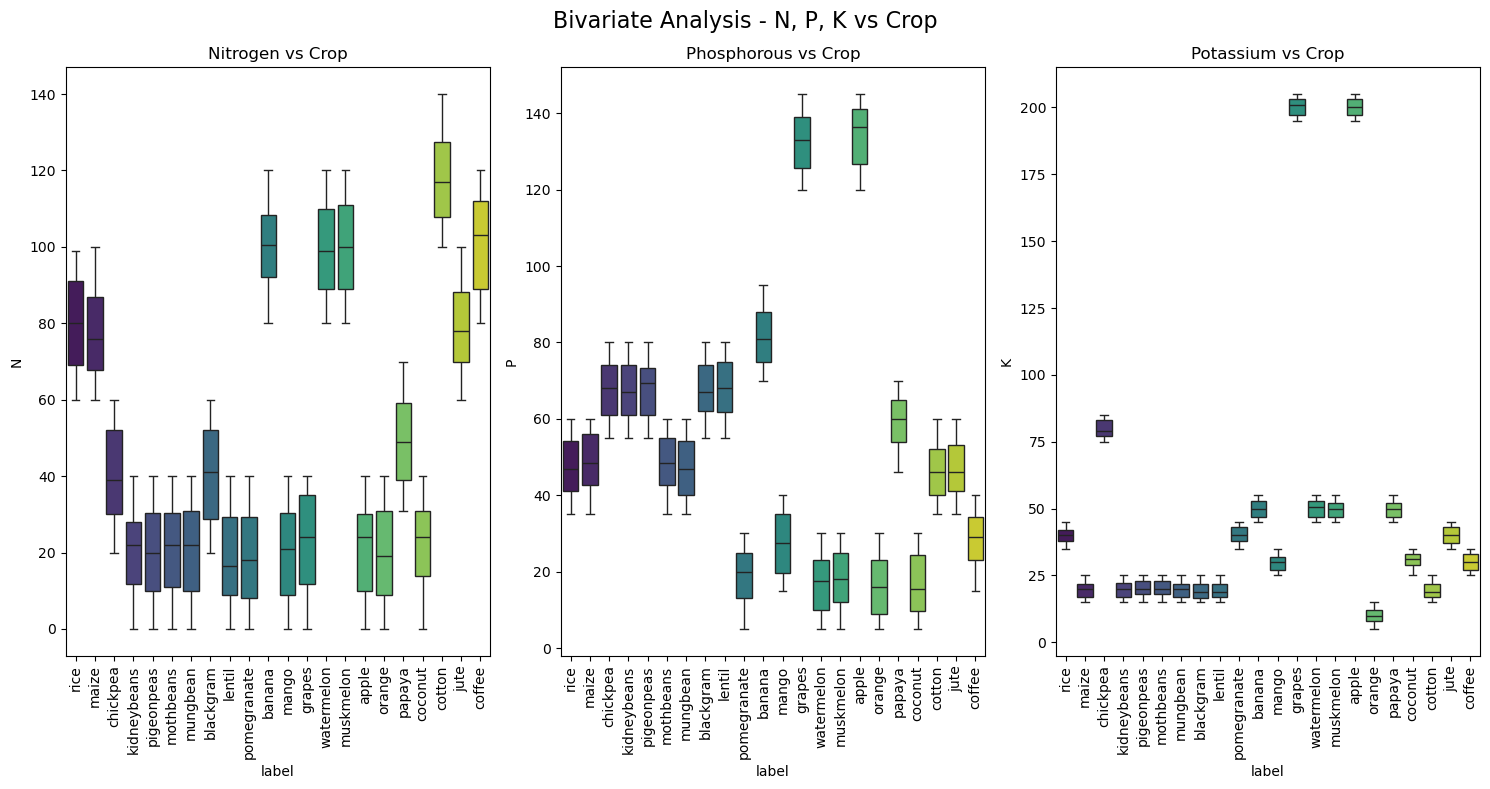

In [5]:
# Bivariate Analysis - Crop wise feature distribution

plt.figure(figsize=(15, 8))
plt.suptitle('Bivariate Analysis - N, P, K vs Crop', fontsize=16)

plt.subplot(1, 3, 1)
sns.boxplot(x='label', y='N', data=data, palette='viridis')
plt.xticks(rotation=90)
plt.title('Nitrogen vs Crop')

plt.subplot(1, 3, 2)
sns.boxplot(x='label', y='P', data=data, palette='viridis')
plt.xticks(rotation=90)
plt.title('Phosphorous vs Crop')

plt.subplot(1, 3, 3)
sns.boxplot(x='label', y='K', data=data, palette='viridis')
plt.xticks(rotation=90)
plt.title('Potassium vs Crop')

plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

Text(0.5, 0.98, 'Bivariate Analysis - Climate vs Crop')

<Axes: >

/tmp/ipykernel_101102/2760480958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='temperature', data=data, palette='coolwarm')


<Axes: xlabel='label', ylabel='temperature'>

...

<Axes: >

/tmp/ipykernel_101102/2760480958.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='rainfall', data=data, palette='Blues')


<Axes: xlabel='label', ylabel='rainfall'>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'rice'),
  Text(1, 0, 'maize'),
  Text(2, 0, 'chickpea'),
  Text(3, 0, 'kidneybeans'),
  Text(4, 0, 'pigeonpeas'),
  Text(5, 0, 'mothbeans'),
  Text(6, 0, 'mungbean'),
  Text(7, 0, 'blackgram'),
  Text(8, 0, 'lentil'),
  Text(9, 0, 'pomegranate'),
  Text(10, 0, 'banana'),
  Text(11, 0, 'mango'),
  Text(12, 0, 'grapes'),
  Text(13, 0, 'watermelon'),
  Text(14, 0, 'muskmelon'),
  Text(15, 0, 'apple'),
  Text(16, 0, 'orange'),
  Text(17, 0, 'papaya'),
  Text(18, 0, 'coconut'),
  Text(19, 0, 'cotton'),
  Text(20, 0, 'jute'),
  Text(21, 0, 'coffee')])

Text(0.5, 1.0, 'Rainfall vs Crop')

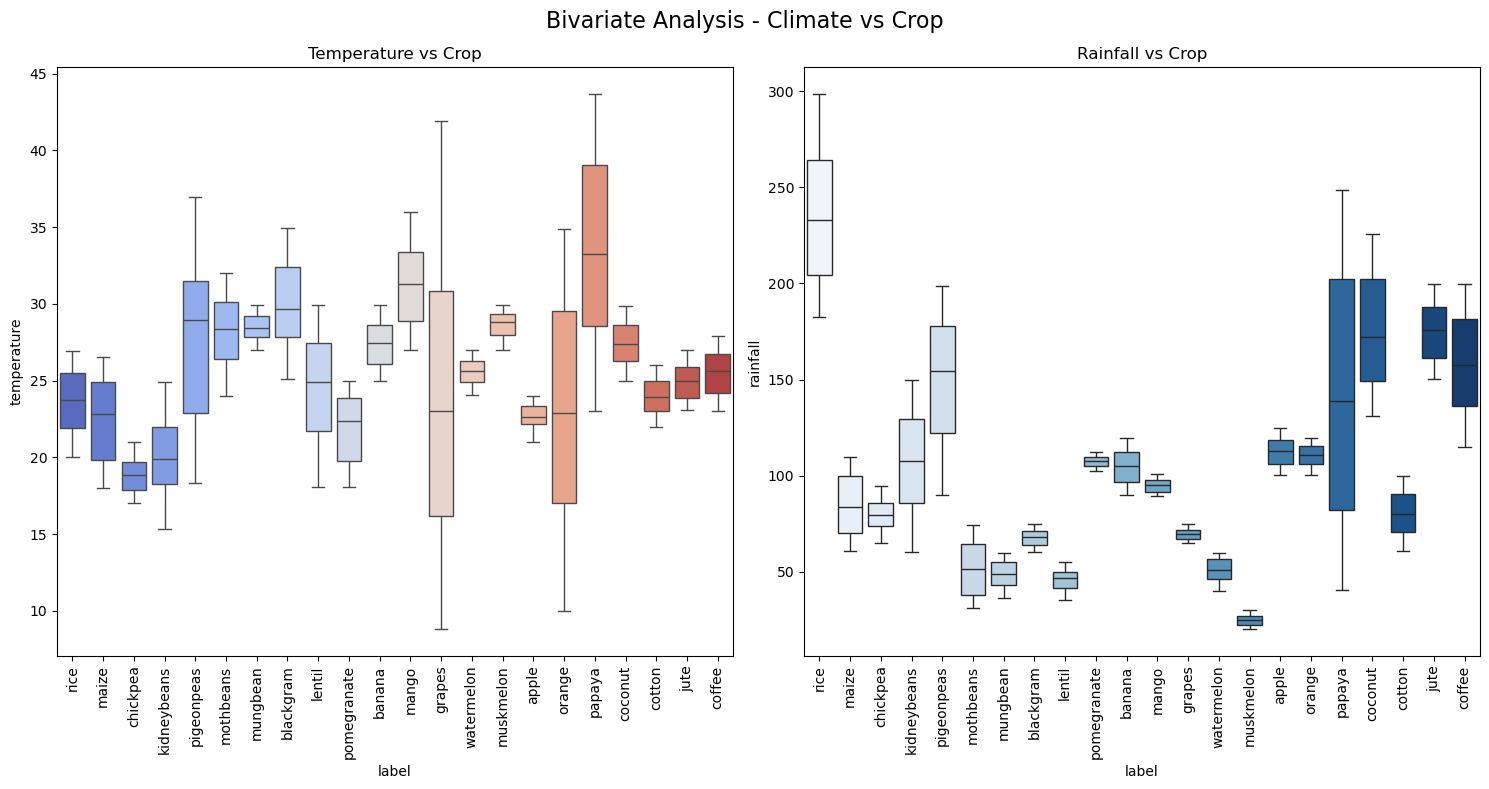

In [6]:
# Climate parameters vs Crop

plt.figure(figsize=(15, 8))
plt.suptitle('Bivariate Analysis - Climate vs Crop', fontsize=16)

plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='temperature', data=data, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Temperature vs Crop')

plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='rainfall', data=data, palette='Blues')
plt.xticks(rotation=90)
plt.title('Rainfall vs Crop')

plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

<Axes: >

/tmp/ipykernel_101102/1511228147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='humidity', data=data, palette='Set2')


<Axes: xlabel='label', ylabel='humidity'>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'rice'),
  Text(1, 0, 'maize'),
  Text(2, 0, 'chickpea'),
  Text(3, 0, 'kidneybeans'),
  Text(4, 0, 'pigeonpeas'),
  Text(5, 0, 'mothbeans'),
  Text(6, 0, 'mungbean'),
  Text(7, 0, 'blackgram'),
  Text(8, 0, 'lentil'),
  Text(9, 0, 'pomegranate'),
  Text(10, 0, 'banana'),
  Text(11, 0, 'mango'),
  Text(12, 0, 'grapes'),
  Text(13, 0, 'watermelon'),
  Text(14, 0, 'muskmelon'),
  Text(15, 0, 'apple'),
  Text(16, 0, 'orange'),
  Text(17, 0, 'papaya'),
  Text(18, 0, 'coconut'),
  Text(19, 0, 'cotton'),
  Text(20, 0, 'jute'),
  Text(21, 0, 'coffee')])

...

<Axes: >

/tmp/ipykernel_101102/1511228147.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='ph', data=data, palette='Set3')


<Axes: xlabel='label', ylabel='ph'>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'rice'),
  Text(1, 0, 'maize'),
  Text(2, 0, 'chickpea'),
  Text(3, 0, 'kidneybeans'),
  Text(4, 0, 'pigeonpeas'),
  Text(5, 0, 'mothbeans'),
  Text(6, 0, 'mungbean'),
  Text(7, 0, 'blackgram'),
  Text(8, 0, 'lentil'),
  Text(9, 0, 'pomegranate'),
  Text(10, 0, 'banana'),
  Text(11, 0, 'mango'),
  Text(12, 0, 'grapes'),
  Text(13, 0, 'watermelon'),
  Text(14, 0, 'muskmelon'),
  Text(15, 0, 'apple'),
  Text(16, 0, 'orange'),
  Text(17, 0, 'papaya'),
  Text(18, 0, 'coconut'),
  Text(19, 0, 'cotton'),
  Text(20, 0, 'jute'),
  Text(21, 0, 'coffee')])

Text(0.5, 1.0, 'pH vs Crop')

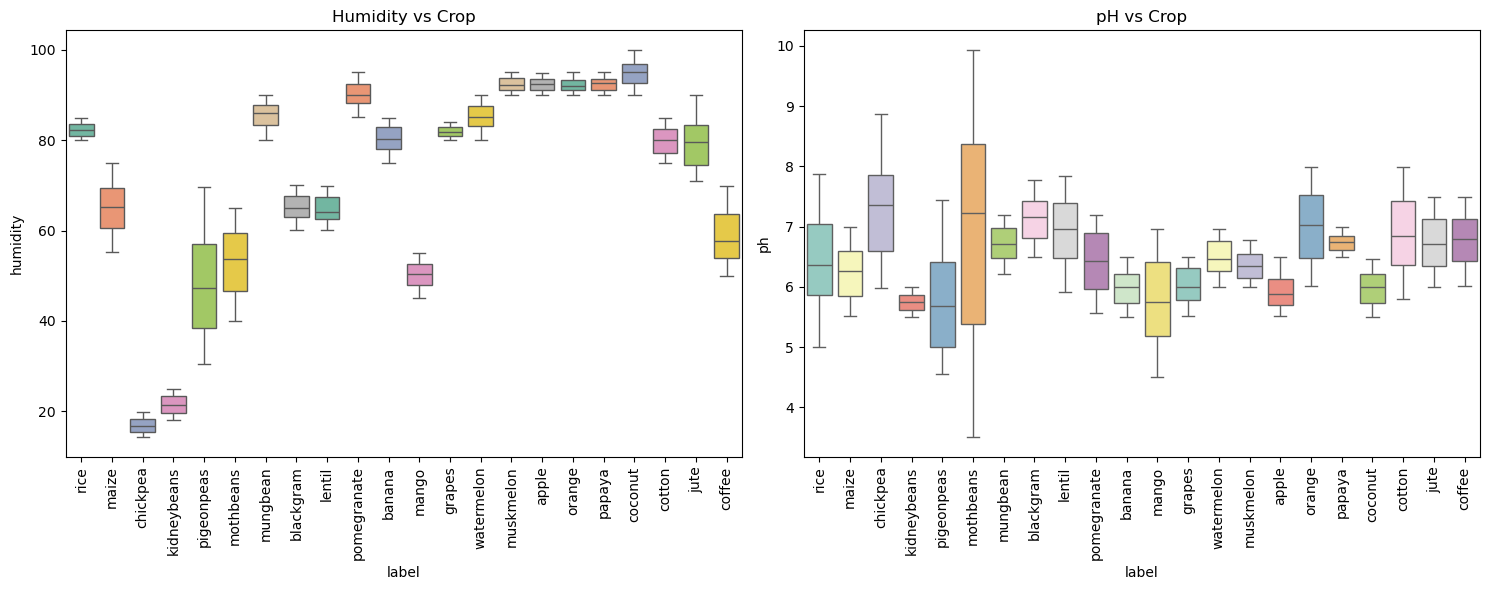

In [7]:
# Humidity and pH vs Crop

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='humidity', data=data, palette='Set2')
plt.xticks(rotation=90)
plt.title('Humidity vs Crop')

plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='ph', data=data, palette='Set3')
plt.xticks(rotation=90)
plt.title('pH vs Crop')

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Bivariate Analysis - Features vs Crop Label')

<Axes: >

<Axes: xlabel='N', ylabel='label'>

<Axes: >

<Axes: xlabel='P', ylabel='label'>

...

<Axes: xlabel='humidity', ylabel='label'>

<Axes: >

<Axes: xlabel='ph', ylabel='label'>

<Axes: >

<Axes: xlabel='rainfall', ylabel='label'>

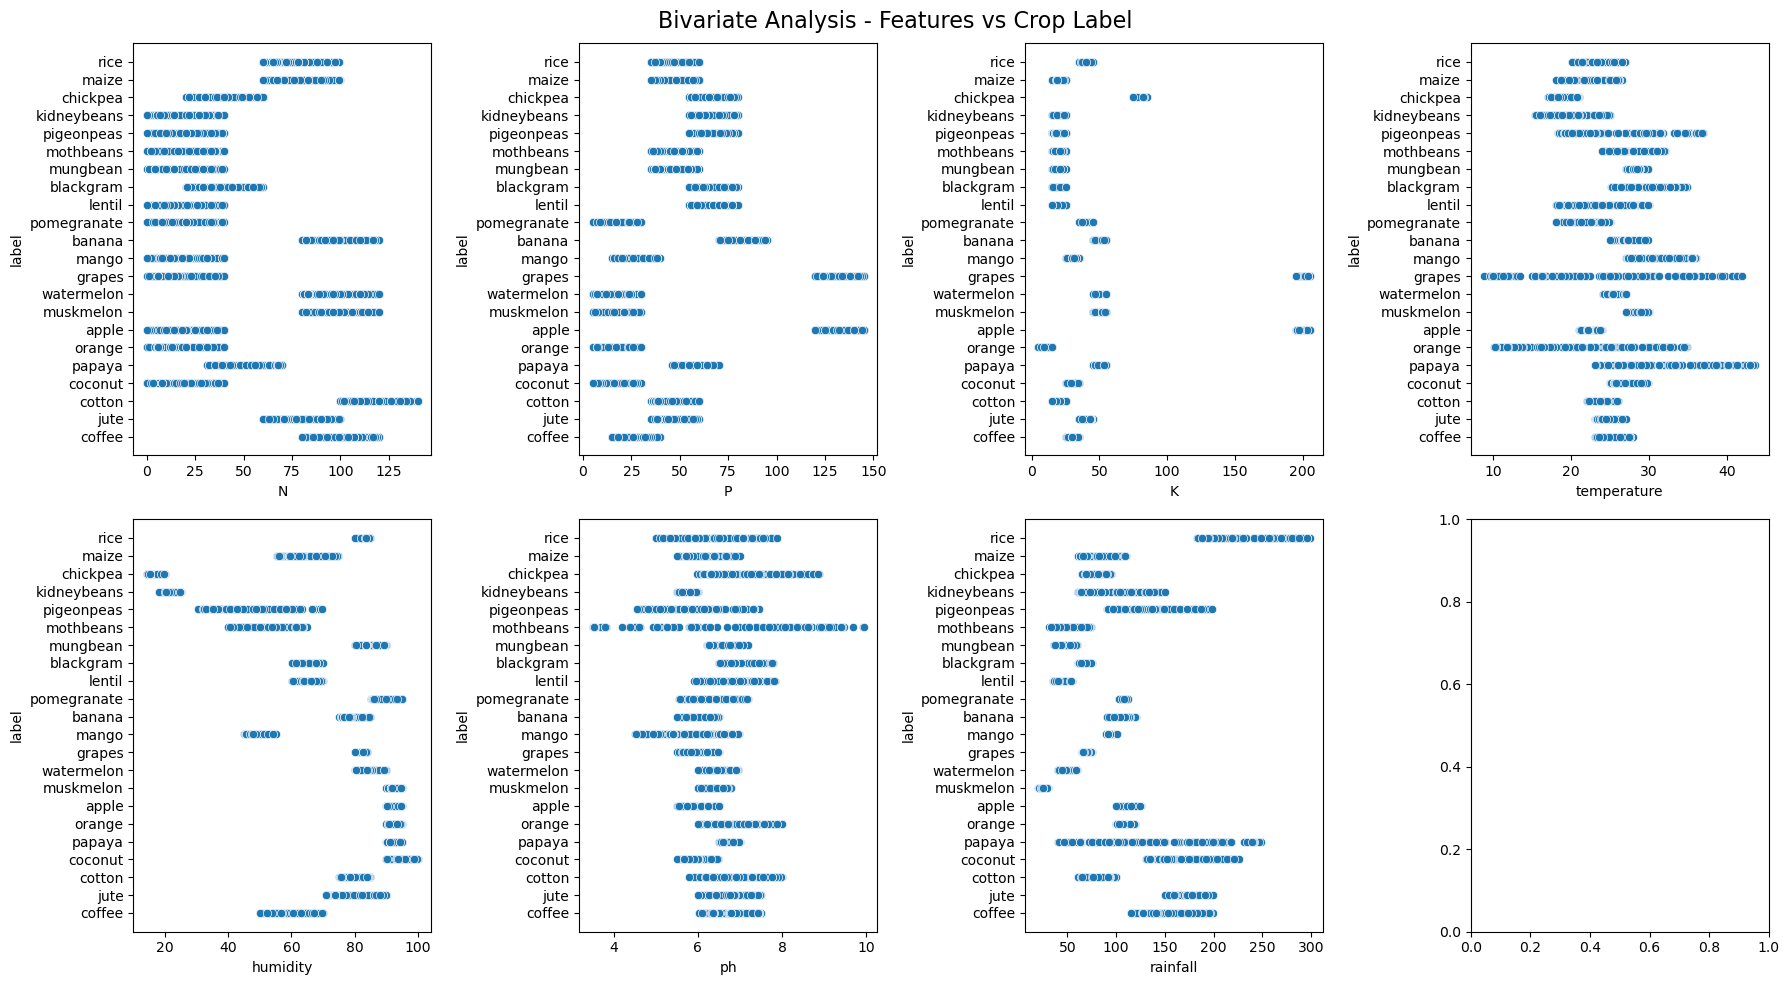

In [8]:
# Bivariate Analysis - Scatter plots
# Rename data to df to match the project convention
df = data

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Bivariate Analysis - Features vs Crop Label', fontsize=16)

plt.subplot(2, 4, 1)
sns.scatterplot(x=df['N'], y=df['label'])

plt.subplot(2, 4, 2)
sns.scatterplot(x=df['P'], y=df['label'])

plt.subplot(2, 4, 3)
sns.scatterplot(x=df['K'], y=df['label'])

plt.subplot(2, 4, 4)
sns.scatterplot(x=df['temperature'], y=df['label'])

plt.subplot(2, 4, 5)
sns.scatterplot(x=df['humidity'], y=df['label'])

plt.subplot(2, 4, 6)
sns.scatterplot(x=df['ph'], y=df['label'])

plt.subplot(2, 4, 7)
sns.scatterplot(x=df['rainfall'], y=df['label'])

plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Pairplot of all Agricultural Features')

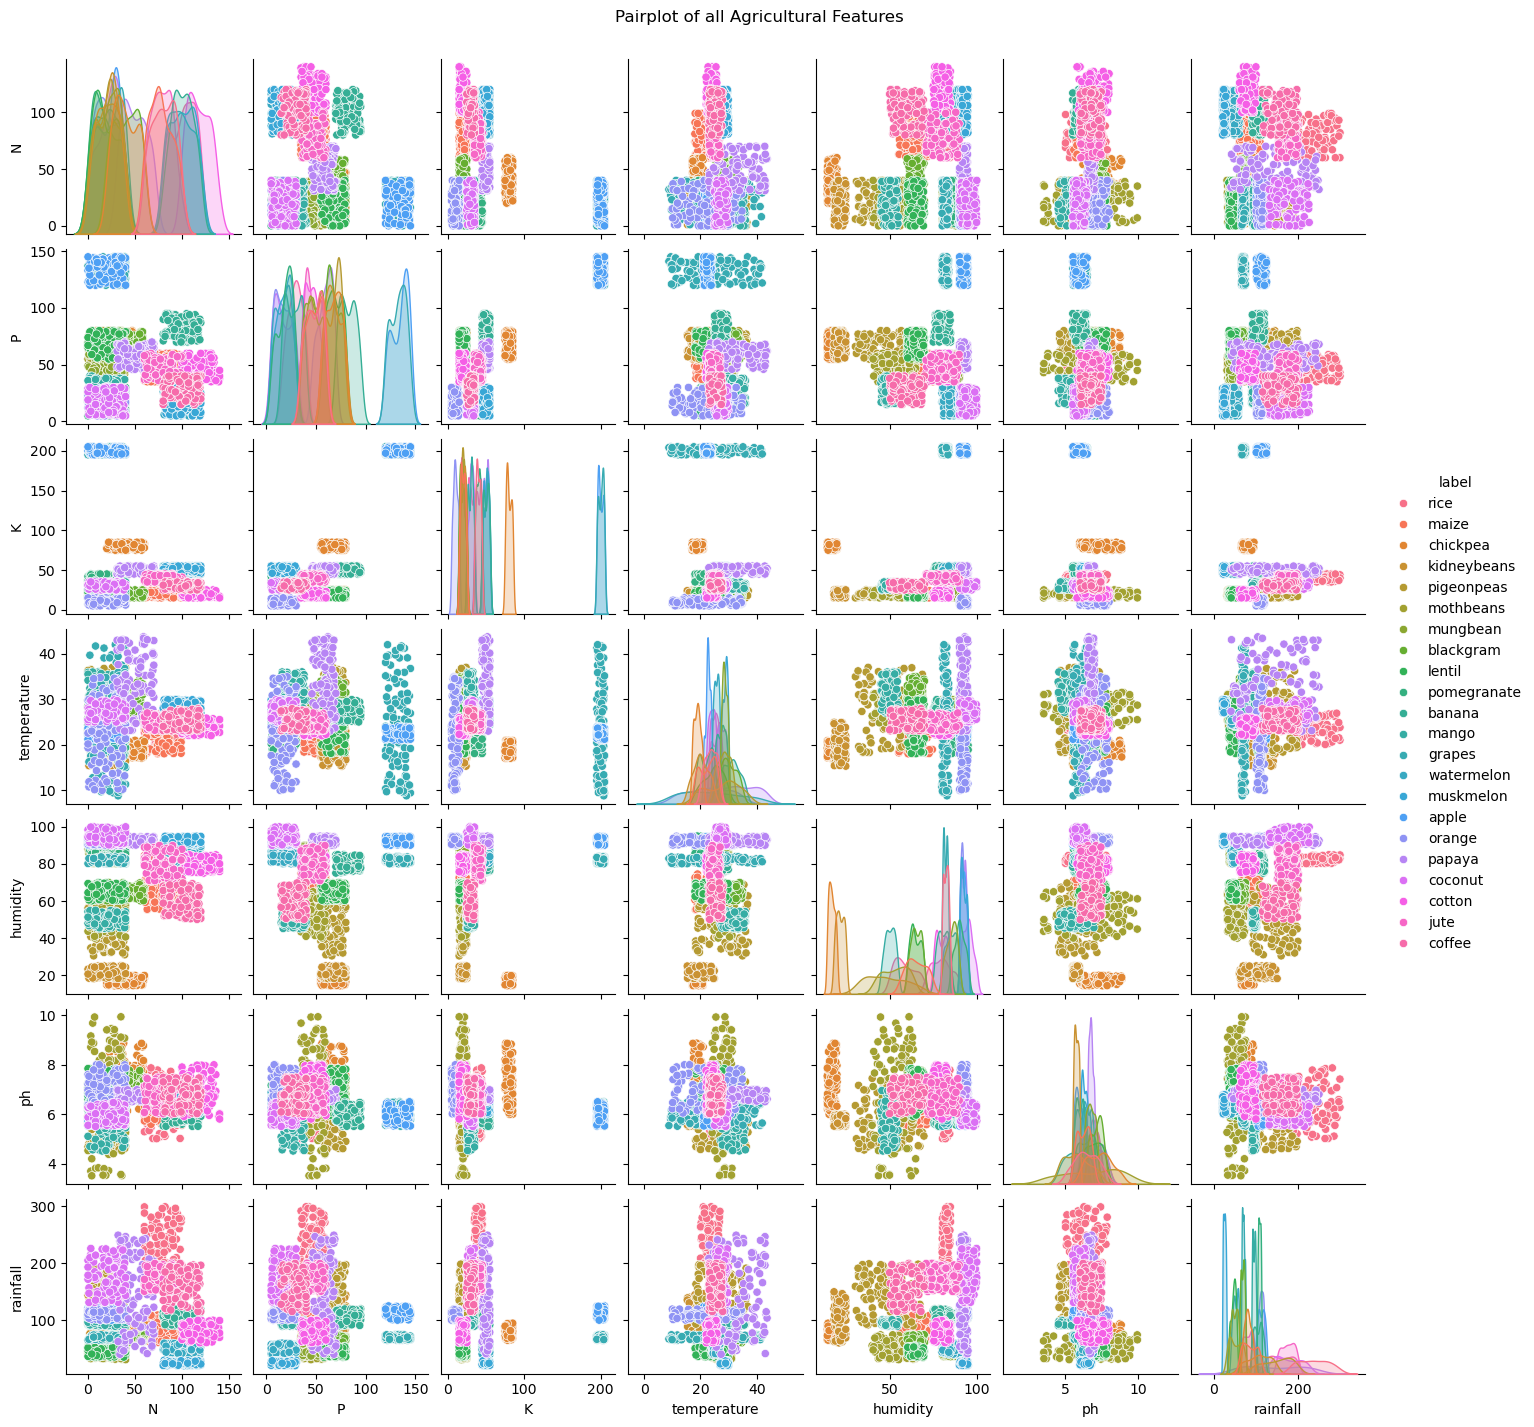

In [9]:
# Pairplot - relationship between all features
sns.pairplot(df, hue='label', height=2)
plt.suptitle('Pairplot of all Agricultural Features', y=1.02)
plt.show()

In [10]:
# Multivariate Analysis - Countplot
sns.countplot(df)

<Axes: ylabel='count'>

<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap of Agricultural Features')

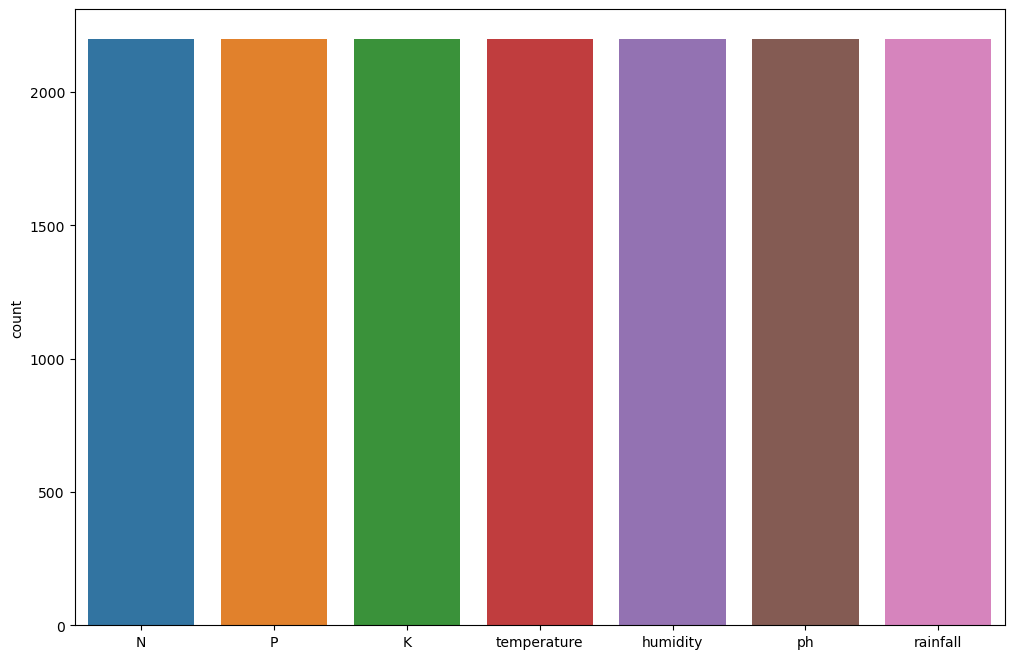

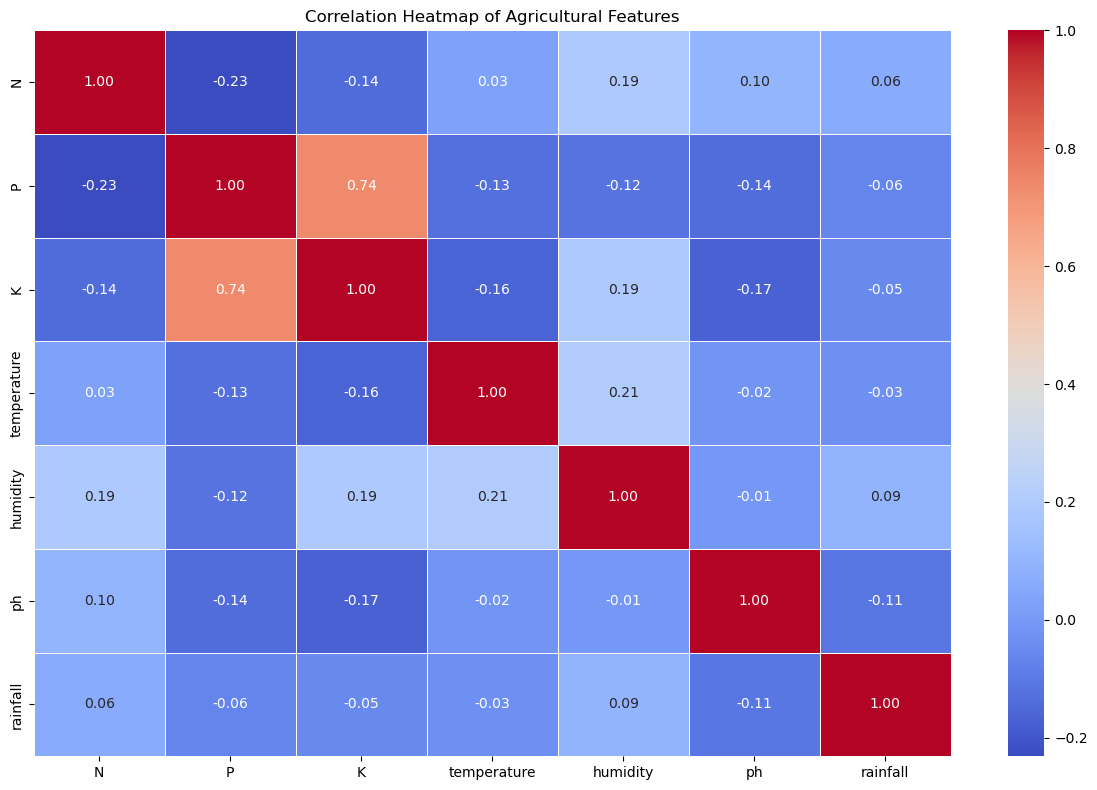

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5)
plt.title('Correlation Heatmap of Agricultural Features')
plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

/tmp/ipykernel_101102/2671084727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


<Axes: xlabel='label', ylabel='count'>

Text(0.5, 1.0, 'Crop Distribution in Dataset')

Text(0.5, 0, 'Crop')

Text(0, 0.5, 'Count')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'rice'),
  Text(1, 0, 'maize'),
  Text(2, 0, 'chickpea'),
  Text(3, 0, 'kidneybeans'),
  Text(4, 0, 'pigeonpeas'),
  Text(5, 0, 'mothbeans'),
  Text(6, 0, 'mungbean'),
  Text(7, 0, 'blackgram'),
  Text(8, 0, 'lentil'),
  Text(9, 0, 'pomegranate'),
  Text(10, 0, 'banana'),
  Text(11, 0, 'mango'),
  Text(12, 0, 'grapes'),
  Text(13, 0, 'watermelon'),
  Text(14, 0, 'muskmelon'),
  Text(15, 0, 'apple'),
  Text(16, 0, 'orange'),
  Text(17, 0, 'papaya'),
  Text(18, 0, 'coconut'),
  Text(19, 0, 'cotton'),
  Text(20, 0, 'jute'),
  Text(21, 0, 'coffee')])

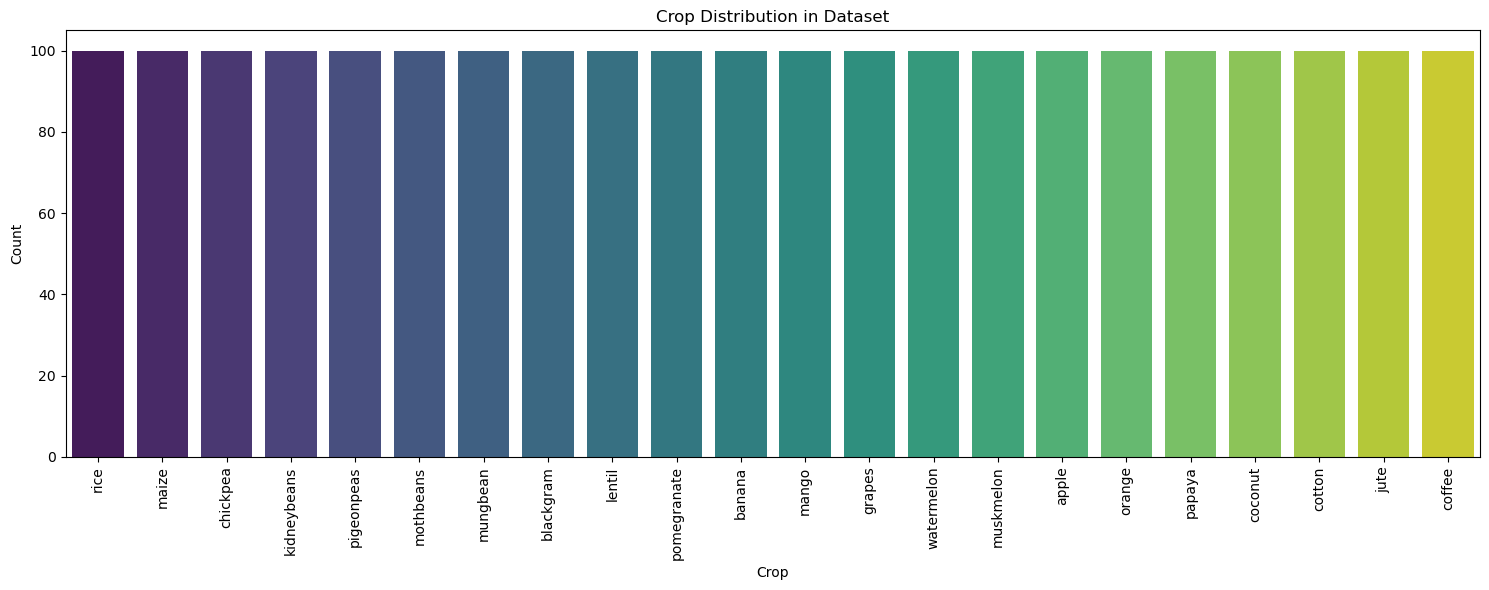

In [12]:
# Crop distribution - how many samples per crop
plt.figure(figsize=(15, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Crop Distribution in Dataset')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:

# Epic 3 - Data Pre-Processing
# Story 1 - Checking for Null Values

# Check null values
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [14]:
# Dataset shape
data.shape

(2200, 8)

In [15]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [16]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
# Drop duplicates if any
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2200, 8)


In [18]:
# Verify no nulls remain
print("Null values after cleaning:")
print(df.isnull().sum())
print("\nDataset is clean and ready for preprocessing!")

Null values after cleaning:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Dataset is clean and ready for preprocessing!


<Figure size 800x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Boxplot to detect outliers')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'N'),
  Text(1, 0, 'P'),
  Text(2, 0, 'K'),
  Text(3, 0, 'temperature'),
  Text(4, 0, 'humidity'),
  Text(5, 0, 'ph'),
  Text(6, 0, 'rainfall')])

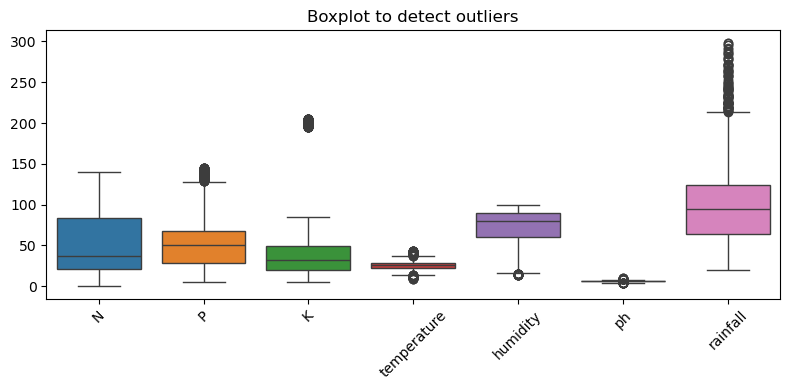

In [19]:
# Story 2 - Handling Outliers
# Step 1 - Visualize outliers using boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(df)
plt.title('Boxplot to detect outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Step 2 - Remove outliers from Phosphorous using IQR method
Q1 = df['P'].quantile(0.25)
Q3 = df['P'].quantile(0.75)
IQR = Q3 - Q1    #IQR is interquartile range.

filter = (df['P'] >= Q1 - 1.5 * IQR) & (df['P'] <= Q3 + 1.5 * IQR)
df = df.loc[filter]
print("Shape after removing Phosphorous outliers:", df.shape)

Shape after removing Phosphorous outliers: (2062, 8)


In [21]:
# Step 3 - Remove outliers from Potassium using IQR method
Q1 = df['K'].quantile(0.25)
Q3 = df['K'].quantile(0.75)
IQR = Q3 - Q1

filter = (df['K'] >= Q1 - 1.5 * IQR) & (df['K'] <= Q3 + 1.5 * IQR)
df = df.loc[filter]
print("Shape after removing Potassium outliers:", df.shape)

Shape after removing Potassium outliers: (2000, 8)


<Figure size 800x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Boxplot after Outlier Removal')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'N'),
  Text(1, 0, 'P'),
  Text(2, 0, 'K'),
  Text(3, 0, 'temperature'),
  Text(4, 0, 'humidity'),
  Text(5, 0, 'ph'),
  Text(6, 0, 'rainfall')])

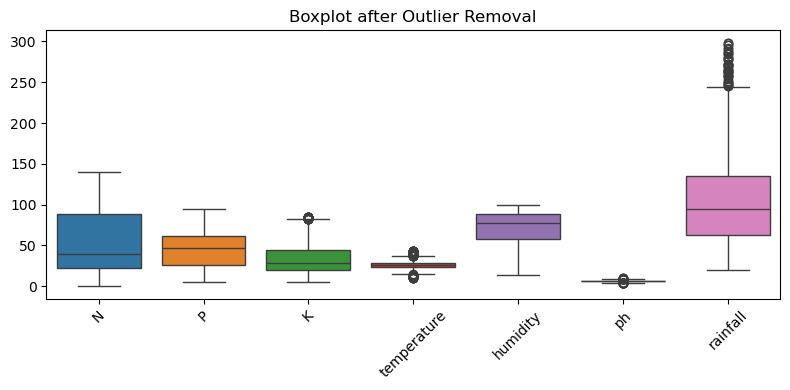

In [22]:
# Step 4 - Verify boxplot after outlier removal
plt.figure(figsize=(8, 4))
sns.boxplot(df)
plt.title('Boxplot after Outlier Removal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Step 5 - Final shape check
print("Final dataset shape after outlier treatment:", df.shape)

Final dataset shape after outlier treatment: (2000, 8)


In [24]:
# Story 3 - Extracting Seasonal Crops

print("Summer crops")
print(df[(df['temperature']>30) & (df['humidity']>50)]['label'].unique())
print("--------------------------------------------")
print("Winter crops")
print(df[(df['temperature']<20) & (df['humidity']>30)]['label'].unique())
print("--------------------------------------------")
print("Rainy crops")
print(df[(df['rainfall']>200) & (df['humidity']>50)]['label'].unique())
print("--------------------------------------------")

Summer crops
['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'orange' 'papaya']
--------------------------------------------
Winter crops
['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'orange']
--------------------------------------------
Rainy crops
['rice' 'papaya' 'coconut']
--------------------------------------------


Text(0.5, 0.98, 'Seasonal Crop Distribution')

<BarContainer object of 6 artists>

Text(0.5, 1.0, 'Summer Crops')

Text(0.5, 0, 'Crop')

Text(0, 0.5, 'Count')

...

Text(0.5, 1.0, 'Winter Crops')

Text(0.5, 0, 'Crop')

<BarContainer object of 3 artists>

Text(0.5, 1.0, 'Rainy Crops')

Text(0.5, 0, 'Crop')

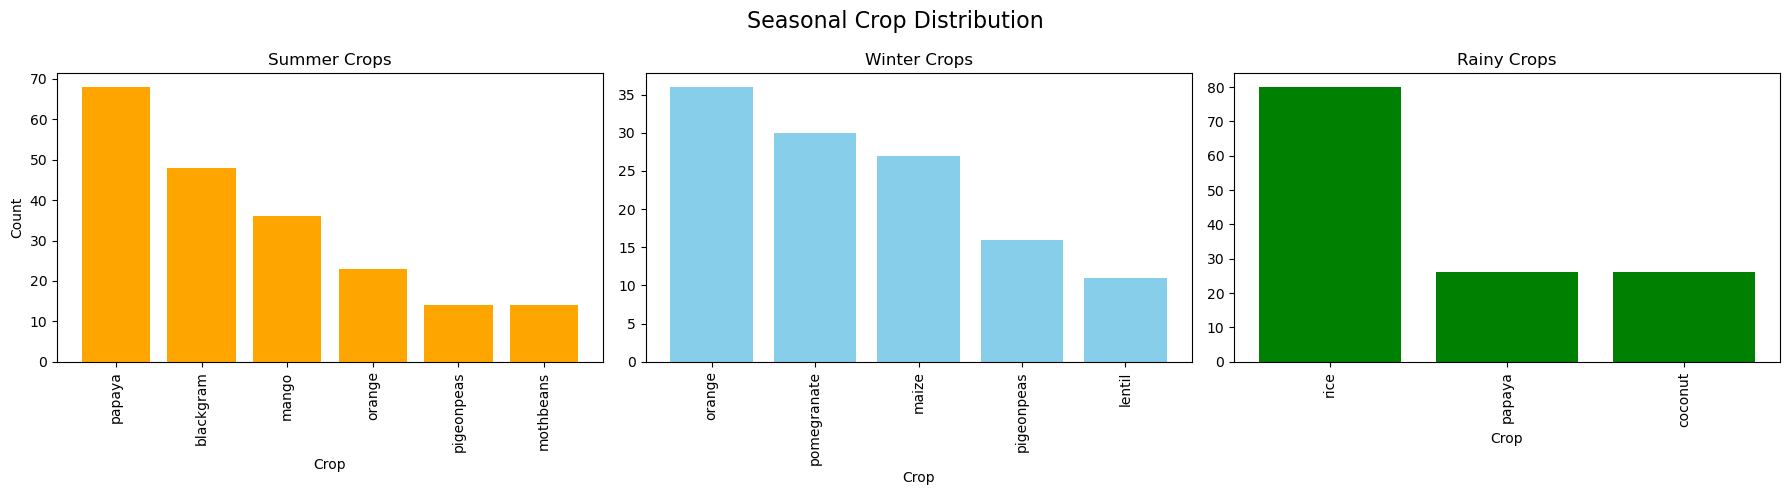

In [25]:
# Visualize seasonal crop distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonal Crop Distribution', fontsize=16)

# Summer crops
summer = df[(df['temperature']>30) & (df['humidity']>50)]
axes[0].bar(summer['label'].value_counts().index, 
            summer['label'].value_counts().values, color='orange')
axes[0].set_title('Summer Crops')
axes[0].set_xlabel('Crop')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# Winter crops
winter = df[(df['temperature']<20) & (df['humidity']>30)]
axes[1].bar(winter['label'].value_counts().index, 
            winter['label'].value_counts().values, color='skyblue')
axes[1].set_title('Winter Crops')
axes[1].set_xlabel('Crop')
axes[1].tick_params(axis='x', rotation=90)

# Rainy crops
rainy = df[(df['rainfall']>200) & (df['humidity']>50)]
axes[2].bar(rainy['label'].value_counts().index, 
            rainy['label'].value_counts().values, color='green')
axes[2].set_title('Rainy Crops')
axes[2].set_xlabel('Crop')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [26]:
# Story 4 - Splitting Data into Train and Test Sets

# Separate features (X) and target (y)
y = df['label']
x = df.drop(['label'], axis=1)

print("Shape of x", x.shape)
print("Shape of x=y", y.shape)

Shape of x (2000, 7)
Shape of x=y (2000,)


In [27]:
# Split into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("The shape of x train", x_train.shape)
print("The shape of x test", x_test.shape)
print("The shape of y train", x_train.shape)
print("The shape of y test", x_test.shape)

The shape of x train (1600, 7)
The shape of x test (400, 7)
The shape of y train (1600, 7)
The shape of y test (400, 7)


KMeans(n_clusters=1, n_init=10, random_state=0)

KMeans(n_clusters=2, n_init=10, random_state=0)

KMeans(n_clusters=3, n_init=10, random_state=0)

KMeans(n_clusters=4, n_init=10, random_state=0)

KMeans(n_clusters=5, n_init=10, random_state=0)

...

KMeans(n_clusters=9, n_init=10, random_state=0)

KMeans(n_clusters=10, n_init=10, random_state=0)

Text(0.5, 1.0, 'The Elbow method')

Text(0.5, 0, 'No of clusters')

Text(0, 0.5, 'wcss')

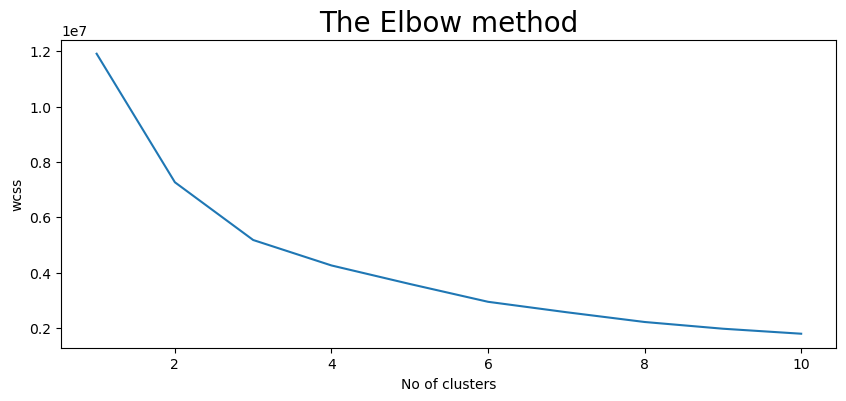

In [28]:
# Elbow Method to find optimal clusters
plt.rcParams['figure.figsize'] = (10, 4)
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init="k-means++", max_iter=300, n_init=10, random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("The Elbow method", fontsize=20)
plt.xlabel("No of clusters")
plt.ylabel("wcss")
plt.show()

In [29]:
# Train K-Means with 4 clusters
km = KMeans(n_clusters=4, init="k-means++", max_iter=300, n_init=10, random_state=0)
y_means = km.fit_predict(x)

a = df['label']
y_means = pd.DataFrame(y_means)
z = pd.concat([y_means, a], axis=1)
z = z.rename(columns={0: 'cluster'})

In [30]:
# Results of K-Means clustering
print("lets check the results after applying the K-Means clustering analysis \n")
print("Crops in First cluster:", z[z['cluster']==0]['label'].unique())
print("________________________________________")
print("Crops in Second cluster:", z[z['cluster']==1]['label'].unique())
print("________________________________________")
print("Crops in Third cluster:", z[z['cluster']==2]['label'].unique())
print("________________________________________")
print("Crops in Fourth cluster:", z[z['cluster']==3]['label'].unique())

lets check the results after applying the K-Means clustering analysis 

Crops in First cluster: ['maize' 'banana' nan 'watermelon' 'papaya' 'cotton']
________________________________________
Crops in Second cluster: ['maize' 'kidneybeans' 'pigeonpeas' 'pomegranate' 'mango' 'muskmelon' nan
 'orange' 'cotton']
________________________________________
Crops in Third cluster: ['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'mango' nan]
________________________________________
Crops in Fourth cluster: ['rice' 'pigeonpeas' nan 'orange' 'coconut' 'cotton']


In [31]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

/home/rguktrkvalley/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [32]:
# Model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Model Accuracy:", accuracy * 100, "%")

Logistic Regression Model Accuracy: 97.0 %


<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression')

Text(120.72222222222221, 0.5, 'Actual')

Text(0.5, 58.7222222222222, 'Predicted')

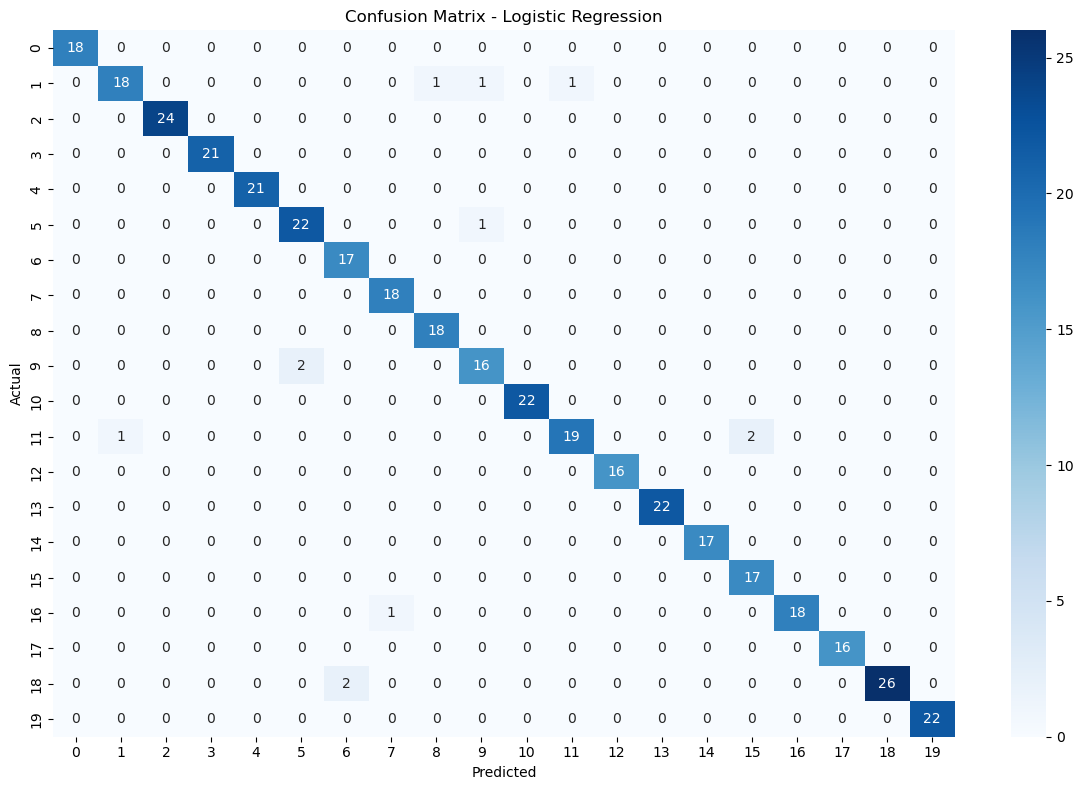

In [33]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [34]:
# Classification Report
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        18
   blackgram       0.95      0.86      0.90        21
    chickpea       1.00      1.00      1.00        24
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        21
      cotton       0.92      0.96      0.94        23
        jute       0.89      1.00      0.94        17
 kidneybeans       0.95      1.00      0.97        18
      lentil       0.95      1.00      0.97        18
       maize       0.89      0.89      0.89        18
       mango       1.00      1.00      1.00        22
   mothbeans       0.95      0.86      0.90        22
    mungbean       1.00      1.00      1.00        16
   muskmelon       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        17
      papaya       0.89      1.00      0.94        17
  pigeonpeas       1.00      0.95      0.97        19
 pom

In [35]:
# Evaluate Logistic Regression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 97.0 %

Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        18
   blackgram       0.95      0.86      0.90        21
    chickpea       1.00      1.00      1.00        24
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        21
      cotton       0.92      0.96      0.94        23
        jute       0.89      1.00      0.94        17
 kidneybeans       0.95      1.00      0.97        18
      lentil       0.95      1.00      0.97        18
       maize       0.89      0.89      0.89        18
       mango       1.00      1.00      1.00        22
   mothbeans       0.95      0.86      0.90        22
    mungbean       1.00      1.00      1.00        16
   muskmelon       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        17
      papaya       0.89      1.00      0.94        17
  pigeonpeas       1

<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression')

Text(120.72222222222221, 0.5, 'Actual')

Text(0.5, 58.7222222222222, 'Predicted')

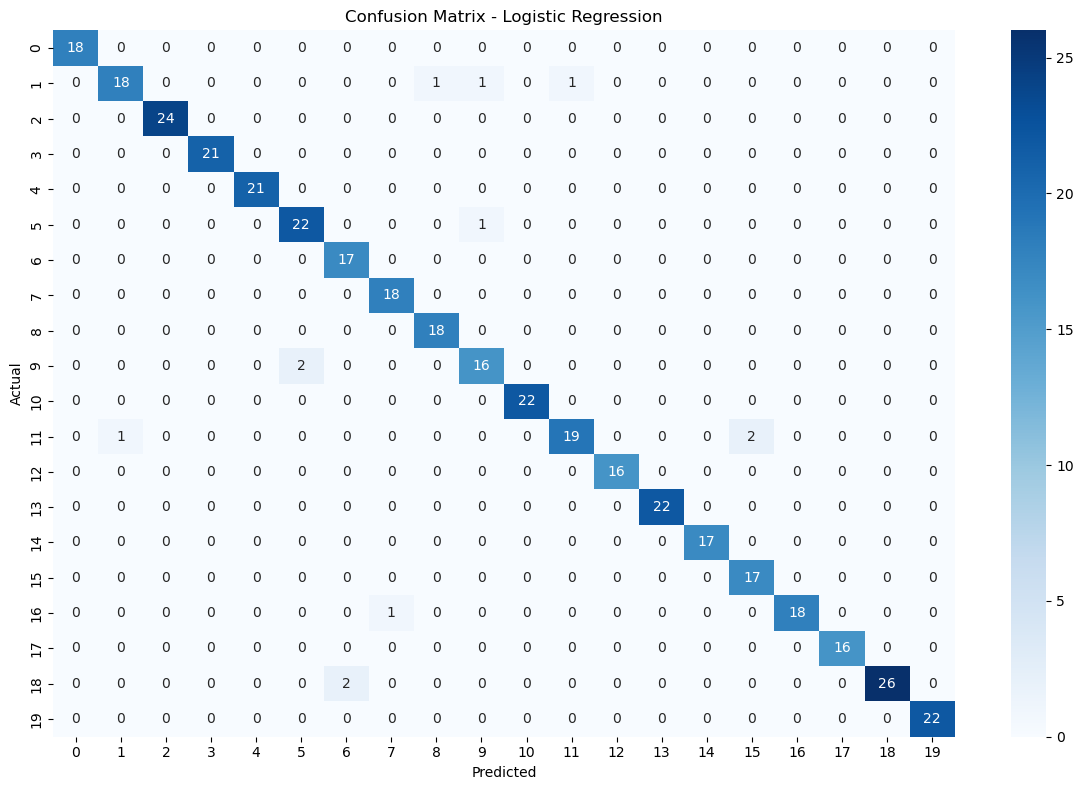

In [36]:
# Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [37]:
# Save the best model using pickle
import pickle

filename = 'model.pkl'
pickle.dump(model, open(filename, 'wb'))
print("Model saved as model.pkl")

Model saved as model.pkl


In [38]:
# Load the saved model and make a prediction
model_loaded = pickle.load(open('model.pkl', 'rb'))

# Sample input: N, P, K, temperature, humidity, ph, rainfall
sample_input = [[90, 42, 43, 20.87, 82.00, 6.50, 202.93]]

prediction = model_loaded.predict(sample_input)
print("Recommended Crop:", prediction[0])

Recommended Crop: rice


/home/rguktrkvalley/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [39]:
# Interactive prediction function
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data = [[N, P, K, temperature, humidity, ph, rainfall]]
    result = model_loaded.predict(input_data)
    print(f"Recommended Crop for given conditions: {result[0]}")

# Test with different values
predict_crop(20, 30, 10, 15, 90, 6.5, 100)
predict_crop(90, 42, 43, 20, 82, 6.5, 202)

Recommended Crop for given conditions: orange
Recommended Crop for given conditions: rice


/home/rguktrkvalley/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/rguktrkvalley/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
